# Optimized Three-Stage Model — MHC Class I with ESM-2 embeddings 


In [1]:
import os
import copy
from contextlib import nullcontext
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)
from Bio.Align import substitution_matrices
import matplotlib.pyplot as plt

DATA_PATH = "/Users/shubhaychoubey/Documents/GitHub/Peptides/Data/ML_Ready/IEDB_ML_ready_with_seq_with_HLA.csv"
CACHE_DIR = "/Users/shubhaychoubey/Documents/GitHub/Peptides/Methods/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MAX_PEP_LEN = 11
N_TOP_BIO = 8
RANDOM_STATE = 42

ESM_MODEL = "facebook/esm2_t6_8M_UR50D"
ESM_DIM = 320

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print("Device:", device)

Device: mps


## 0. Install the ESM-2 dependency



In [2]:
!pip install -q transformers

## 1. Load class I data, drop leaks, split

Same as the class I three-stage notebook: drop identity/label-leaking columns, keep rows with a usable sequence, label,
and an allele we have a groove sequence for, then a stratified 70/15/15 split.


In [3]:
hla_library = {
    "HLA-A*24:02": (
        "GSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DEETGKVKAHSQTDRENLRIALRYYNQSEAGSHTLQMMFGCDVGSDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQITKRKWEAAHVAEQQRAYLEGTCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*02:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*32:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAHSQTDRESLRIALRYYNQSEAGSHTIQMMYGCDVGPDGRLLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*15:10": (
        "GSHSMRYFYTAMSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQICKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-C*03:04": (
        "GSHSMRYFYTAVSRPGRGEPHFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLKNGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-C*14:02": (
        "CSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHTLQWMFGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-B*44:02": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQDRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*57:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*03:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHEAEQLRAYLDGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-C*05:01": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVQFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVNLRKLRGYYNQSEAGSHTLQRMYGCDLGPDGRLLRGYNQFAYDG"
        "KDYIALNEDLRSWTAADKAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKKTLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-B*27:05": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRETQICKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*51:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRENLRIALRYYNQSEAGSHTWQTMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*40:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQISQRKLEAARVAEQLRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*40:02": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*07:02": (
        "GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQIYKAQAQTDRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*18:01": (
        "GSHSMRYFHTSVSRPGRGEPRFISVGYVDGTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*25:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAHSQTDRESLRIALRYYNQSEDGSHTIQRMYGCDVGPDGRFLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWETAHEAEQWRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*44:03": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*30:01": (
        "GSHSMRYFSTSVSRPGSGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQERPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYEQHAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARWAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*11:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHAAEQQRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-C*12:03": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQADRVSLRNLRGYYNQSEAGSHTLQWMYGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
    "HLA-B*49:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRIALRYYNQSEAGSHTWQRMYGCDLGPDGRLLRGYNQLAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*01:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKMEPRAPWIEQEGPEYW"
        "DQETRNMKAHSQTDRANLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAVHAAEQRRVYLEGRCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*15:02": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*35:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDLGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-A*68:02": (
        "GSHSMRYFYTSMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQRMYGCDVGPDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWVAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
    "HLA-B*15:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQWRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
}

print("HLA class I alleles:", len(hla_library))

HLA class I alleles: 27


In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)

LEAKY_COLS = ["Disease", "strat_key", "found_in_healthy", "ID", "Tissue",
              "hla_population_freq", "Uniprot IDs", "source", "hla_source",
              "hla_known", "feature_error", "Affinity % Rank", "affinity_bin",
              "is_strong_binder", "is_weak_binder", "is_non_binder",
              "ms_confirmed", "MHC Class", "Peptide Modifications", "length_class"]
df = df.drop(columns=LEAKY_COLS, errors="ignore")

df = df.dropna(subset=["is_cancer", "Peptide Sequence", "Best HLA Allele"])
df = df[df["Best HLA Allele"].isin(hla_library.keys())].reset_index(drop=True)
df["is_cancer"] = df["is_cancer"].astype(int)

print(f"rows: {len(df):,}   alleles: {df['Best HLA Allele'].nunique()}")
print(df["is_cancer"].value_counts().rename({0: "healthy", 1: "cancer"}).to_string())

train_df, test_df = train_test_split(df, test_size=0.15, random_state=RANDOM_STATE, stratify=df["is_cancer"])
train_df, val_df = train_test_split(train_df, test_size=0.1765, random_state=RANDOM_STATE, stratify=train_df["is_cancer"])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"\nTrain {len(train_df):,}   Val {len(val_df):,}   Test {len(test_df):,}")

rows: 43,678   alleles: 27
is_cancer
healthy    22051
cancer     21627

Train 30,573   Val 6,553   Test 6,552


## 2. Peptide and HLA-groove sequences



In [5]:
NETMHCPAN_POS34 = [7, 9, 24, 45, 59, 62, 63, 66, 67, 69, 70, 73, 74, 76, 77, 80, 81, 84,
                   95, 97, 99, 114, 116, 118, 143, 147, 150, 152, 156, 158, 159, 163, 167, 171]
PSEUDO_POS = NETMHCPAN_POS34

def hla_pseudosequence(allele):
    seq = hla_library[allele]
    return "".join(seq[p - 1] if p - 1 < len(seq) else "-" for p in PSEUDO_POS)

pseudo_map = {a: hla_pseudosequence(a) for a in hla_library}
PSEUDO_LEN = len(PSEUDO_POS)
n_distinct = len(set(pseudo_map.values()))
print("pseudosequence length:", PSEUDO_LEN)
print("distinct pseudosequences:", n_distinct, "/", len(pseudo_map))
assert n_distinct == len(pseudo_map), "pseudosequence collision"

pseudosequence length: 34
distinct pseudosequences: 27 / 27


## 3. ESM-2 embedding — the new preprocessing step




In [6]:
from transformers import AutoTokenizer, AutoModel

esm_tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL)
esm_model = AutoModel.from_pretrained(ESM_MODEL).to(device).eval()

@torch.no_grad()
def esm_residue_embeddings(sequences, batch_size=32):
    cache = {}
    unique = list(dict.fromkeys(str(s).upper() for s in sequences))
    for start in range(0, len(unique), batch_size):
        chunk = unique[start:start + batch_size]
        enc = esm_tokenizer(chunk, return_tensors="pt", padding=True, add_special_tokens=True)
        enc = {k: v.to(device) for k, v in enc.items()}
        hidden = esm_model(**enc).last_hidden_state
        for j, seq in enumerate(chunk):
            length = len(seq)
            cache[seq] = hidden[j, 1:1 + length].float().cpu().numpy().astype(np.float32)
    return cache

demo_seq = str(train_df["Peptide Sequence"].iloc[0]).upper()
demo = esm_residue_embeddings([demo_seq])
print("peptide:", demo_seq, "-> ESM-2 residue embeddings", demo[demo_seq].shape)

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


peptide: ATVAVPLVGK -> ESM-2 residue embeddings (10, 320)


In [7]:
all_peptides = pd.concat([train_df, val_df, test_df])["Peptide Sequence"].astype(str).str.upper().unique().tolist()
all_grooves = list(dict.fromkeys(pseudo_map.values()))

PEP_EMB = esm_residue_embeddings(all_peptides)
MHC_EMB = esm_residue_embeddings(all_grooves)
print("cached peptide embeddings:", len(PEP_EMB))
print("cached groove embeddings :", len(MHC_EMB))

cached peptide embeddings: 34834
cached groove embeddings : 27


## 4. Biophysical features + Dataset / DataLoader



In [8]:
EXCLUDE = set(["is_cancer", "Peptide Sequence", "Best HLA Allele"])
BIO_CANDIDATES = [c for c in train_df.columns
                  if c not in EXCLUDE and pd.api.types.is_numeric_dtype(train_df[c])]

X_sel = (train_df[BIO_CANDIDATES].replace([np.inf, -np.inf], np.nan)
         .fillna(train_df[BIO_CANDIDATES].mean(numeric_only=True)).fillna(0))
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_sel, train_df["is_cancer"])
importance = pd.Series(rf.feature_importances_, index=BIO_CANDIDATES).sort_values(ascending=False)
TOP8 = importance.head(N_TOP_BIO).index.tolist()

print(f"top {N_TOP_BIO} biophysical features:")
for i, feat in enumerate(TOP8, 1):
    print(f"  {i}. {feat}  ({importance[feat]:.4f})")

bio_scaler = StandardScaler().fit(X_sel[TOP8].values)

top 8 biophysical features:
  1. molecular_weight  (0.0755)
  2. tcr_contact_hydro_mean  (0.0731)
  3. boman_index  (0.0715)
  4. hydrophobicity_GRAVY  (0.0714)
  5. instability_index  (0.0705)
  6. charge_pH_7  (0.0639)
  7. isoelectric_point  (0.0517)
  8. aliphatic_index  (0.0452)


In [9]:
class PeptideMHCESMDataset(Dataset):
    def __init__(self, frame, scaler):
        self.pep = frame["Peptide Sequence"].astype(str).str.upper().tolist()
        self.allele = frame["Best HLA Allele"].tolist()
        self.labels = frame["is_cancer"].astype(int).values
        bio = (frame[TOP8].replace([np.inf, -np.inf], np.nan)
               .fillna(frame[TOP8].mean(numeric_only=True)).fillna(0).values)
        self.bio = scaler.transform(bio).astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        pep_emb = PEP_EMB[self.pep[i]]
        length = min(pep_emb.shape[0], MAX_PEP_LEN)
        pep_pad = np.zeros((MAX_PEP_LEN, ESM_DIM), dtype=np.float32)
        pep_pad[:length] = pep_emb[:length]
        pad_mask = np.ones(MAX_PEP_LEN, dtype=bool)
        pad_mask[:length] = False
        mhc_emb = MHC_EMB[pseudo_map[self.allele[i]]]
        return {
            "bio": torch.from_numpy(self.bio[i]),
            "pep": torch.from_numpy(pep_pad),
            "pep_mask": torch.from_numpy(pad_mask),
            "mhc": torch.from_numpy(mhc_emb),
            "label": torch.tensor(self.labels[i], dtype=torch.long),
        }

train_ds = PeptideMHCESMDataset(train_df, bio_scaler)
val_ds = PeptideMHCESMDataset(val_df, bio_scaler)
test_ds = PeptideMHCESMDataset(test_df, bio_scaler)

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

probe_batch = next(iter(train_loader))
print("batch shapes:")
for key, value in probe_batch.items():
    print(f"  {key:9s}: {tuple(value.shape)}  {value.dtype}")

batch shapes:
  bio      : (128, 8)  torch.float32
  pep      : (128, 11, 320)  torch.float32
  pep_mask : (128, 11)  torch.bool
  mhc      : (128, 34, 320)  torch.float32
  label    : (128,)  torch.int64


## 5. NEW OPTIM optimized model (ESM input width)




In [10]:
class BetterThreeStageModel(nn.Module):
    def __init__(self, n_bio=N_TOP_BIO, d_model=96, n_heads=4, n_layers_pep=3,
                 n_layers_mhc=2, max_pep=MAX_PEP_LEN, in_dim=20, dropout=0.25):
        super().__init__()

        self.bio_mlp = nn.Sequential(
            nn.Linear(n_bio, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.pep_proj = nn.Linear(in_dim, d_model)
        self.pep_pos = nn.Embedding(max_pep, d_model)

        pep_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.pep_encoder = nn.TransformerEncoder(
            pep_layer, num_layers=n_layers_pep, enable_nested_tensor=False,
        )

        self.mhc_proj = nn.Linear(in_dim, d_model)
        self.mhc_pos = nn.Embedding(PSEUDO_LEN, d_model)

        mhc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.mhc_encoder = nn.TransformerEncoder(
            mhc_layer, num_layers=n_layers_mhc, enable_nested_tensor=False,
        )

        self.pep_to_mhc = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.mhc_to_pep = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.pep_cross_norm = nn.LayerNorm(d_model)
        self.mhc_cross_norm = nn.LayerNorm(d_model)

        self.fusion_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.fusion_norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 5),
            nn.Linear(d_model * 5, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 2),
        )

    def masked_mean(self, x, pad_mask):
        keep = (~pad_mask).unsqueeze(-1).float()
        return (x * keep).sum(dim=1) / keep.sum(dim=1).clamp(min=1.0)

    def forward(self, bio, pep, pep_mask, mhc):
        B = bio.size(0)

        bio_tok = self.bio_mlp(bio)

        pep_pos = torch.arange(pep.size(1), device=pep.device).unsqueeze(0)
        pep_x = self.pep_proj(pep) + self.pep_pos(pep_pos)
        pep_x = self.pep_encoder(pep_x, src_key_padding_mask=pep_mask)
        pep_tok = self.masked_mean(pep_x, pep_mask)

        mhc_pos = torch.arange(mhc.size(1), device=mhc.device).unsqueeze(0)
        mhc_x = self.mhc_proj(mhc) + self.mhc_pos(mhc_pos)
        mhc_x = self.mhc_encoder(mhc_x)
        mhc_tok = mhc_x.mean(dim=1)

        pep_cross, _ = self.pep_to_mhc(query=pep_x, key=mhc_x, value=mhc_x)
        pep_cross = self.pep_cross_norm(pep_x + pep_cross)
        pep_mhc_tok = self.masked_mean(pep_cross, pep_mask)

        mhc_cross, _ = self.mhc_to_pep(query=mhc_x, key=pep_x, value=pep_x, key_padding_mask=pep_mask)
        mhc_cross = self.mhc_cross_norm(mhc_x + mhc_cross)
        mhc_pep_tok = mhc_cross.mean(dim=1)

        tokens = torch.stack([bio_tok, pep_tok, mhc_tok, pep_mhc_tok, mhc_pep_tok], dim=1)
        fused, _ = self.fusion_attn(tokens, tokens, tokens)
        fused = self.fusion_norm(tokens + fused)

        logits = self.classifier(fused.reshape(B, -1))
        return logits

## 6. NEW OPTIM training system


In [11]:
CFG = {
    "d_model": 96,
    "n_heads": 4,
    "n_layers_pep": 3,
    "n_layers_mhc": 2,
    "in_dim": ESM_DIM,
    "dropout": 0.25,
    "lr": 7e-4,
    "weight_decay": 1e-3,
    "epochs": 40,
    "patience": 8,
    "grad_clip": 1.0,
    "label_smoothing": 0.03,
    "use_class_weights": False,
    "score_metric": "val_acc",
    "checkpoint_name": "better_threestage_classI_esm2_best.pt",
}


def seed_everything(seed=RANDOM_STATE):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def to_device(batch):
    return (
        batch["bio"].to(device),
        batch["pep"].to(device),
        batch["pep_mask"].to(device),
        batch["mhc"].to(device),
        batch["label"].to(device),
    )


def get_class_weights(frame):
    counts = np.bincount(frame["is_cancer"].astype(int).values)
    weights = counts.sum() / (2.0 * counts)
    return torch.tensor(weights, dtype=torch.float32).to(device)


def build_model(cfg):
    model = BetterThreeStageModel(
        d_model=cfg["d_model"],
        n_heads=cfg["n_heads"],
        n_layers_pep=cfg["n_layers_pep"],
        n_layers_mhc=cfg["n_layers_mhc"],
        in_dim=cfg["in_dim"],
        dropout=cfg["dropout"],
    ).to(device)
    return model


def build_loss(cfg):
    weights = get_class_weights(train_df) if cfg["use_class_weights"] else None
    return nn.CrossEntropyLoss(weight=weights, label_smoothing=cfg["label_smoothing"])


def build_optimizer(model, cfg):
    return torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])


def build_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


def dry_run_model(model, loss_fn):
    model.train()
    batch = next(iter(train_loader))
    bio, pep, pep_mask, mhc, label = to_device(batch)
    logits = model(bio, pep, pep_mask, mhc)
    assert logits.shape == (bio.size(0), 2), f"bad output shape {logits.shape}"
    assert not torch.isnan(logits).any(), "NaNs in logits"
    loss = loss_fn(logits, label)
    loss.backward()
    grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
    print("dry run passed")
    print("output shape:", tuple(logits.shape))
    print("loss:", round(loss.item(), 4))
    print("grad norm:", round(grad_norm, 4))
    model.zero_grad()


def run_epoch(model, loader, loss_fn, optimizer=None, scaler=None, cfg=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_true, all_pred, all_prob = [], [], []
    use_amp = device.type == "cuda"
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            bio, pep, pep_mask, mhc, label = to_device(batch)
            amp_context = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()
            with amp_context:
                logits = model(bio, pep, pep_mask, mhc)
                loss = loss_fn(logits, label)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
                    optimizer.step()
            total_loss += loss.item() * label.size(0)
            prob = torch.softmax(logits.detach(), dim=1)[:, 1]
            pred = logits.detach().argmax(dim=1)
            all_true.extend(label.cpu().tolist())
            all_pred.extend(pred.cpu().tolist())
            all_prob.extend(prob.cpu().tolist())
    avg_loss = total_loss / len(all_true)
    acc = accuracy_score(all_true, all_pred)
    bal_acc = balanced_accuracy_score(all_true, all_pred)
    try:
        auc = roc_auc_score(all_true, all_prob)
    except ValueError:
        auc = 0.0
    return {"loss": avg_loss, "acc": acc, "bal_acc": bal_acc, "auc": auc,
            "true": all_true, "pred": all_pred, "prob": all_prob}


def get_score(metrics, metric_name):
    return {"val_acc": metrics["acc"], "val_bal_acc": metrics["bal_acc"], "val_auc": metrics["auc"]}[metric_name]


def train_model(cfg):
    seed_everything()
    model = build_model(cfg)
    loss_fn = build_loss(cfg)
    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    ckpt_path = os.path.join(CACHE_DIR, cfg["checkpoint_name"])

    print(model)
    print("trainable params:", count_params(model))
    dry_run_model(model, loss_fn)

    best_score, best_state, wait = -1, None, 0
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
            "train_bal_acc": [], "val_bal_acc": [], "train_auc": [], "val_auc": []}

    for epoch in range(1, cfg["epochs"] + 1):
        train_metrics = run_epoch(model, train_loader, loss_fn, optimizer=optimizer, scaler=scaler, cfg=cfg)
        val_metrics = run_epoch(model, val_loader, loss_fn, cfg=cfg)

        for key, tag in [("loss", "loss"), ("acc", "acc"), ("bal_acc", "bal_acc"), ("auc", "auc")]:
            hist["train_" + tag].append(train_metrics[key])
            hist["val_" + tag].append(val_metrics[key])

        score = get_score(val_metrics, cfg["score_metric"])
        scheduler.step(score)

        print(f"epoch {epoch:02d} | train loss {train_metrics['loss']:.4f} acc {train_metrics['acc']:.4f} "
              f"bal {train_metrics['bal_acc']:.4f} auc {train_metrics['auc']:.4f} | "
              f"val loss {val_metrics['loss']:.4f} acc {val_metrics['acc']:.4f} "
              f"bal {val_metrics['bal_acc']:.4f} auc {val_metrics['auc']:.4f}")

        if score > best_score:
            best_score, best_state, wait = score, copy.deepcopy(model.state_dict()), 0
            torch.save(best_state, ckpt_path)
        else:
            wait += 1
            if wait >= cfg["patience"]:
                print(f"early stopping at epoch {epoch}")
                break

    print(f"\nbest {cfg['score_metric']}: {best_score:.4f}")
    print(f"saved to: {ckpt_path}")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, hist, ckpt_path


def collect_outputs(model, loader):
    model.eval()
    all_true, all_prob = [], []
    with torch.no_grad():
        for batch in loader:
            bio, pep, pep_mask, mhc, label = to_device(batch)
            logits = model(bio, pep, pep_mask, mhc)
            prob = torch.softmax(logits, dim=1)[:, 1]
            all_true.extend(label.cpu().tolist())
            all_prob.extend(prob.cpu().tolist())
    return np.array(all_true), np.array(all_prob)


def find_best_threshold(y_true, y_prob, metric="balanced_accuracy"):
    best_t, best_score = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= t).astype(int)
        score = balanced_accuracy_score(y_true, pred) if metric == "balanced_accuracy" else accuracy_score(y_true, pred)
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score


def evaluate_model(model, loader, threshold=0.5, title="TEST SET"):
    y_true, y_prob = collect_outputs(model, loader)
    y_pred = (y_prob >= threshold).astype(int)
    print(f"===== {title} =====")
    print(f"threshold:         {threshold:.3f}")
    print(f"accuracy:          {accuracy_score(y_true, y_pred):.4f}")
    print(f"balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"roc auc:           {roc_auc_score(y_true, y_prob):.4f}")
    print("\nclassification report:")
    print(classification_report(y_true, y_pred, target_names=["healthy", "cancer"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["healthy", "cancer"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["healthy", "cancer"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    plt.tight_layout(); plt.show()
    return {"true": y_true, "prob": y_prob, "pred": y_pred}


def plot_history(hist):
    plt.figure(figsize=(7, 4))
    plt.plot(hist["train_acc"], label="train acc")
    plt.plot(hist["val_acc"], label="val acc")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("accuracy curve"); plt.legend()
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["train_auc"], label="train auc")
    plt.plot(hist["val_auc"], label="val auc")
    plt.xlabel("epoch"); plt.ylabel("roc auc"); plt.title("auc curve"); plt.legend()
    plt.tight_layout(); plt.show()

## 7. Dry run — verify shapes and gradients (fast)

Builds the model and runs one batch of ESM-2 tensors forward + backward. Confirms `(B, 2)` output, no NaNs, and
gradient flow through the 320-d projections.


In [12]:
seed_everything()
probe_model = build_model(CFG)
print("trainable params:", count_params(probe_model))
dry_run_model(probe_model, build_loss(CFG))

trainable params: 860066
dry run passed
output shape: (128, 2)
loss: 0.6995
grad norm: 1.3268


## 8. Train 


BetterThreeStageModel(
  (bio_mlp): Sequential(
    (0): Linear(in_features=8, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=96, out_features=96, bias=True)
    (5): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
  )
  (pep_proj): Linear(in_features=320, out_features=96, bias=True)
  (pep_pos): Embedding(11, 96)
  (pep_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=384, bias=True)
        (dropout): Dropout(p=0.25, inplace=False)
        (linear2): Linear(in_features=384, out_features=96, bias=True)
        (norm1): LayerNorm((96,)

/var/folders/vs/1x2cctjj76q80zjkdspl6hd80000gn/T/ipykernel_95170/4211838484.py:141: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


epoch 01 | train loss 0.5570 acc 0.6904 bal 0.6909 auc 0.7802 | val loss 0.4850 acc 0.7459 bal 0.7476 auc 0.8698
epoch 02 | train loss 0.4467 acc 0.7950 bal 0.7953 auc 0.8842 | val loss 0.4062 acc 0.8131 bal 0.8142 auc 0.9087
epoch 03 | train loss 0.4067 acc 0.8158 bal 0.8159 auc 0.9076 | val loss 0.4063 acc 0.8219 bal 0.8215 auc 0.9152
epoch 04 | train loss 0.3993 acc 0.8176 bal 0.8175 auc 0.9112 | val loss 0.3910 acc 0.8186 bal 0.8180 auc 0.9175
epoch 05 | train loss 0.3933 acc 0.8212 bal 0.8211 auc 0.9147 | val loss 0.3945 acc 0.8257 bal 0.8259 auc 0.9177
epoch 06 | train loss 0.3903 acc 0.8216 bal 0.8216 auc 0.9162 | val loss 0.3842 acc 0.8225 bal 0.8219 auc 0.9200
epoch 07 | train loss 0.3886 acc 0.8250 bal 0.8251 auc 0.9178 | val loss 0.3885 acc 0.8234 bal 0.8228 auc 0.9203
epoch 08 | train loss 0.3851 acc 0.8254 bal 0.8254 auc 0.9192 | val loss 0.3843 acc 0.8228 bal 0.8224 auc 0.9200
epoch 09 | train loss 0.3792 acc 0.8259 bal 0.8260 auc 0.9217 | val loss 0.3790 acc 0.8253 bal 0

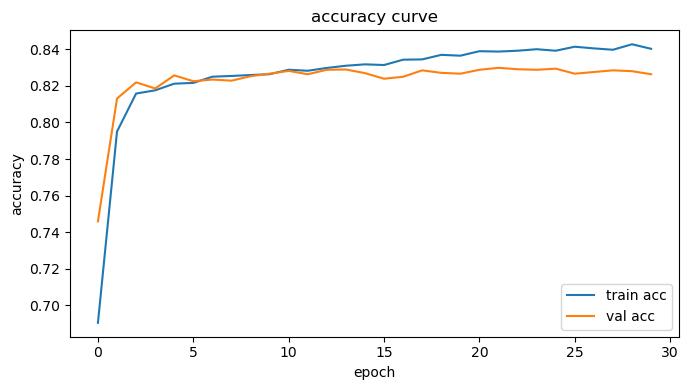

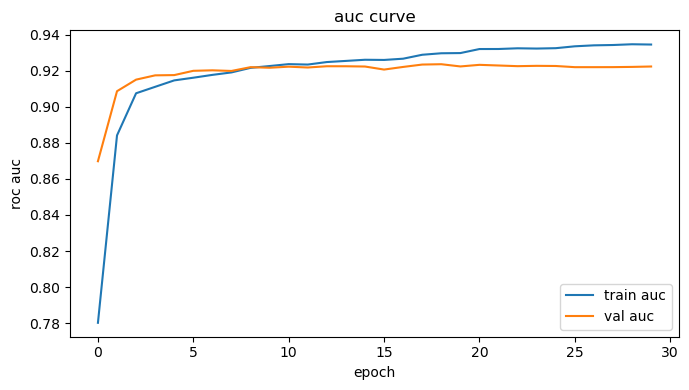

best validation threshold: 0.52  accuracy: 0.8317
===== TEST SET DEFAULT THRESHOLD =====
threshold:         0.500
accuracy:          0.8329
balanced accuracy: 0.8332
roc auc:           0.9254

classification report:
              precision    recall  f1-score   support

     healthy     0.8587    0.8008    0.8287      3308
      cancer     0.8099    0.8656    0.8368      3244

    accuracy                         0.8329      6552
   macro avg     0.8343    0.8332    0.8328      6552
weighted avg     0.8345    0.8329    0.8327      6552



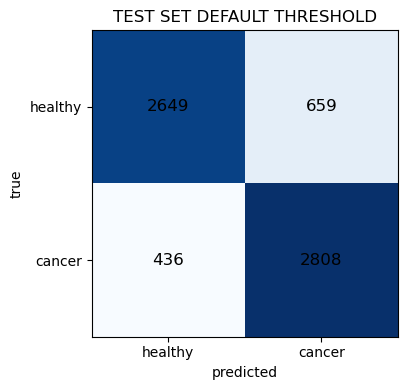

===== TEST SET TUNED THRESHOLD =====
threshold:         0.520
accuracy:          0.8341
balanced accuracy: 0.8341
roc auc:           0.9254

classification report:
              precision    recall  f1-score   support

     healthy     0.8401    0.8292    0.8346      3308
      cancer     0.8281    0.8391    0.8336      3244

    accuracy                         0.8341      6552
   macro avg     0.8341    0.8341    0.8341      6552
weighted avg     0.8342    0.8341    0.8341      6552



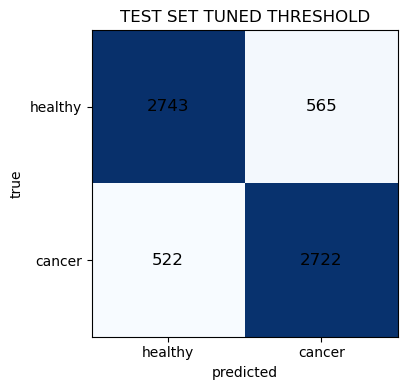

{'true': array([1, 1, 1, ..., 0, 0, 0], shape=(6552,)),
 'prob': array([0.97844088, 0.97819126, 0.87781721, ..., 0.1105902 , 0.01328428,
        0.96340752], shape=(6552,)),
 'pred': array([1, 1, 1, ..., 0, 0, 1], shape=(6552,))}

In [13]:
model, hist, ckpt_path = train_model(CFG)
plot_history(hist)

val_true, val_prob = collect_outputs(model, val_loader)
best_threshold, best_val = find_best_threshold(val_true, val_prob, metric="accuracy")
print("best validation threshold:", round(best_threshold, 3), " accuracy:", round(best_val, 4))

evaluate_model(model, test_loader, threshold=0.5, title="TEST SET DEFAULT THRESHOLD")
evaluate_model(model, test_loader, threshold=best_threshold, title="TEST SET TUNED THRESHOLD")